In [1]:
## 15-1: 최종 14개 지표 원본값(raw, 표준화 전) 재구성
## — 09/11/13번 노트북의 병합 로직을 그대로 재현

import pandas as pd
import geopandas as gpd

# 1) 09번 산출물 (14개 중 IDW_mean·풍속·습도 제외 11개 raw + 재계산 전 pop_peak_h/pop_lunch_)
df = pd.read_csv('grid_HSI_selected_indicators.csv')
print("기본:", df.shape)

# 2) IDW_mean 추가 (11번 로직)
idw = gpd.read_file('Grid_IDW_mean_max_FINAL.gpkg')[['grid_id', 'Grid_IDW_mean_sample_SAMPLE_1']]
idw = idw.rename(columns={'Grid_IDW_mean_sample_SAMPLE_1': 'IDW_mean'})
df = pd.merge(df, idw, on='grid_id', how='left')
print("IDW_mean 추가 후:", df.shape)

# 3) 풍속·습도 추가 (13번 로직)
weather = pd.read_csv('격자30m_2024_월별_기상_통합.csv')
windspeed_cols = [c for c in weather.columns if c.startswith('windspeed_')]
rh_cols = [c for c in weather.columns if c.startswith('rh_')]
weather['windspeed_mean'] = weather[windspeed_cols].mean(axis=1, skipna=True)
weather['rh_mean'] = weather[rh_cols].mean(axis=1, skipna=True)
weather['grid_id'] = weather['grid_id'].astype('Int64')
df = df.merge(weather[['grid_id', 'windspeed_mean', 'rh_mean']], on='grid_id', how='left')
print("풍속·습도 추가 후:", df.shape)

# 4) pop_peak_h(방문인구)·pop_lunch_(직장인구) 11~17시로 재계산 (13번 로직)
df_hourly = pd.read_csv('grid_HSI_final_merged.csv', usecols=['grid_id'] +
    [f'work_{h:02d}h' for h in range(24)] + [f'visi_{h:02d}h' for h in range(24)])

visi_1117 = [f'visi_{h:02d}h' for h in range(11, 18)]
work_1117 = [f'work_{h:02d}h' for h in range(11, 18)]
df_hourly['pop_peak_h_v2'] = df_hourly[visi_1117].mean(axis=1)
df_hourly['pop_lunch_v2'] = df_hourly[work_1117].mean(axis=1)

df = df.merge(df_hourly[['grid_id', 'pop_peak_h_v2', 'pop_lunch_v2']], on='grid_id', how='left')
df = df.drop(columns=['pop_peak_h', 'pop_lunch_'])
df = df.rename(columns={'pop_peak_h_v2': 'pop_peak_h', 'pop_lunch_v2': 'pop_lunch_'})

# 5) adaptive_facility_total 통합 (park+shade+cooling+smart)
df['adaptive_facility_total'] = (
    df['park_cnt'] + df['shade_cnt'] +
    df['cooling_shelter_cnt'] + df['smart_shelter_cnt']
)

print("\n최종 shape:", df.shape)
print(df.columns.tolist())

df.to_csv('grid_HSI_14indicators_raw_final.csv', index=False, encoding='utf-8-sig')
print("\n저장 완료: grid_HSI_14indicators_raw_final.csv")

기본: (11388, 22)
IDW_mean 추가 후: (11388, 23)
풍속·습도 추가 후: (11388, 25)

최종 shape: (11388, 26)
['grid_id', 'geometry', 'ADM_SIDO', 'ADM_SGG_CD', 'ADM_EMD_CD', 'ADM_EMD_NM', 'lon', 'lat', 'pop_elderl', 'park_cnt', 'shade_cnt', 'cooling_shelter_cnt', 'daycare_cnt', 'smart_shelter_cnt', 'tree_road_len', 'NDVI_mean_5scene', 'LST_C_mean_5scene', 'LC1_100_시가화건조지역_ratio', 'GREEN_ratio_LC', 'senior_facility_total', 'IDW_mean', 'windspeed_mean', 'rh_mean', 'pop_peak_h', 'pop_lunch_', 'adaptive_facility_total']

저장 완료: grid_HSI_14indicators_raw_final.csv


/tmp/ipykernel_9/1081179476.py:36: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/1081179476.py:36: UserWarning: Glyph 51333 (\N{HANGUL SYLLABLE JONG}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/1081179476.py:36: UserWarning: Glyph 44060 (\N{HANGUL SYLLABLE GAE}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/1081179476.py:36: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE JI}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/1081179476.py:36: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/1081179476.py:36: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/1081179476.py:36: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from current font.
  plt.tight_layout()
/tmp/ipykernel_9/1081179476.py:36: UserWarning: Glyph 44050 (

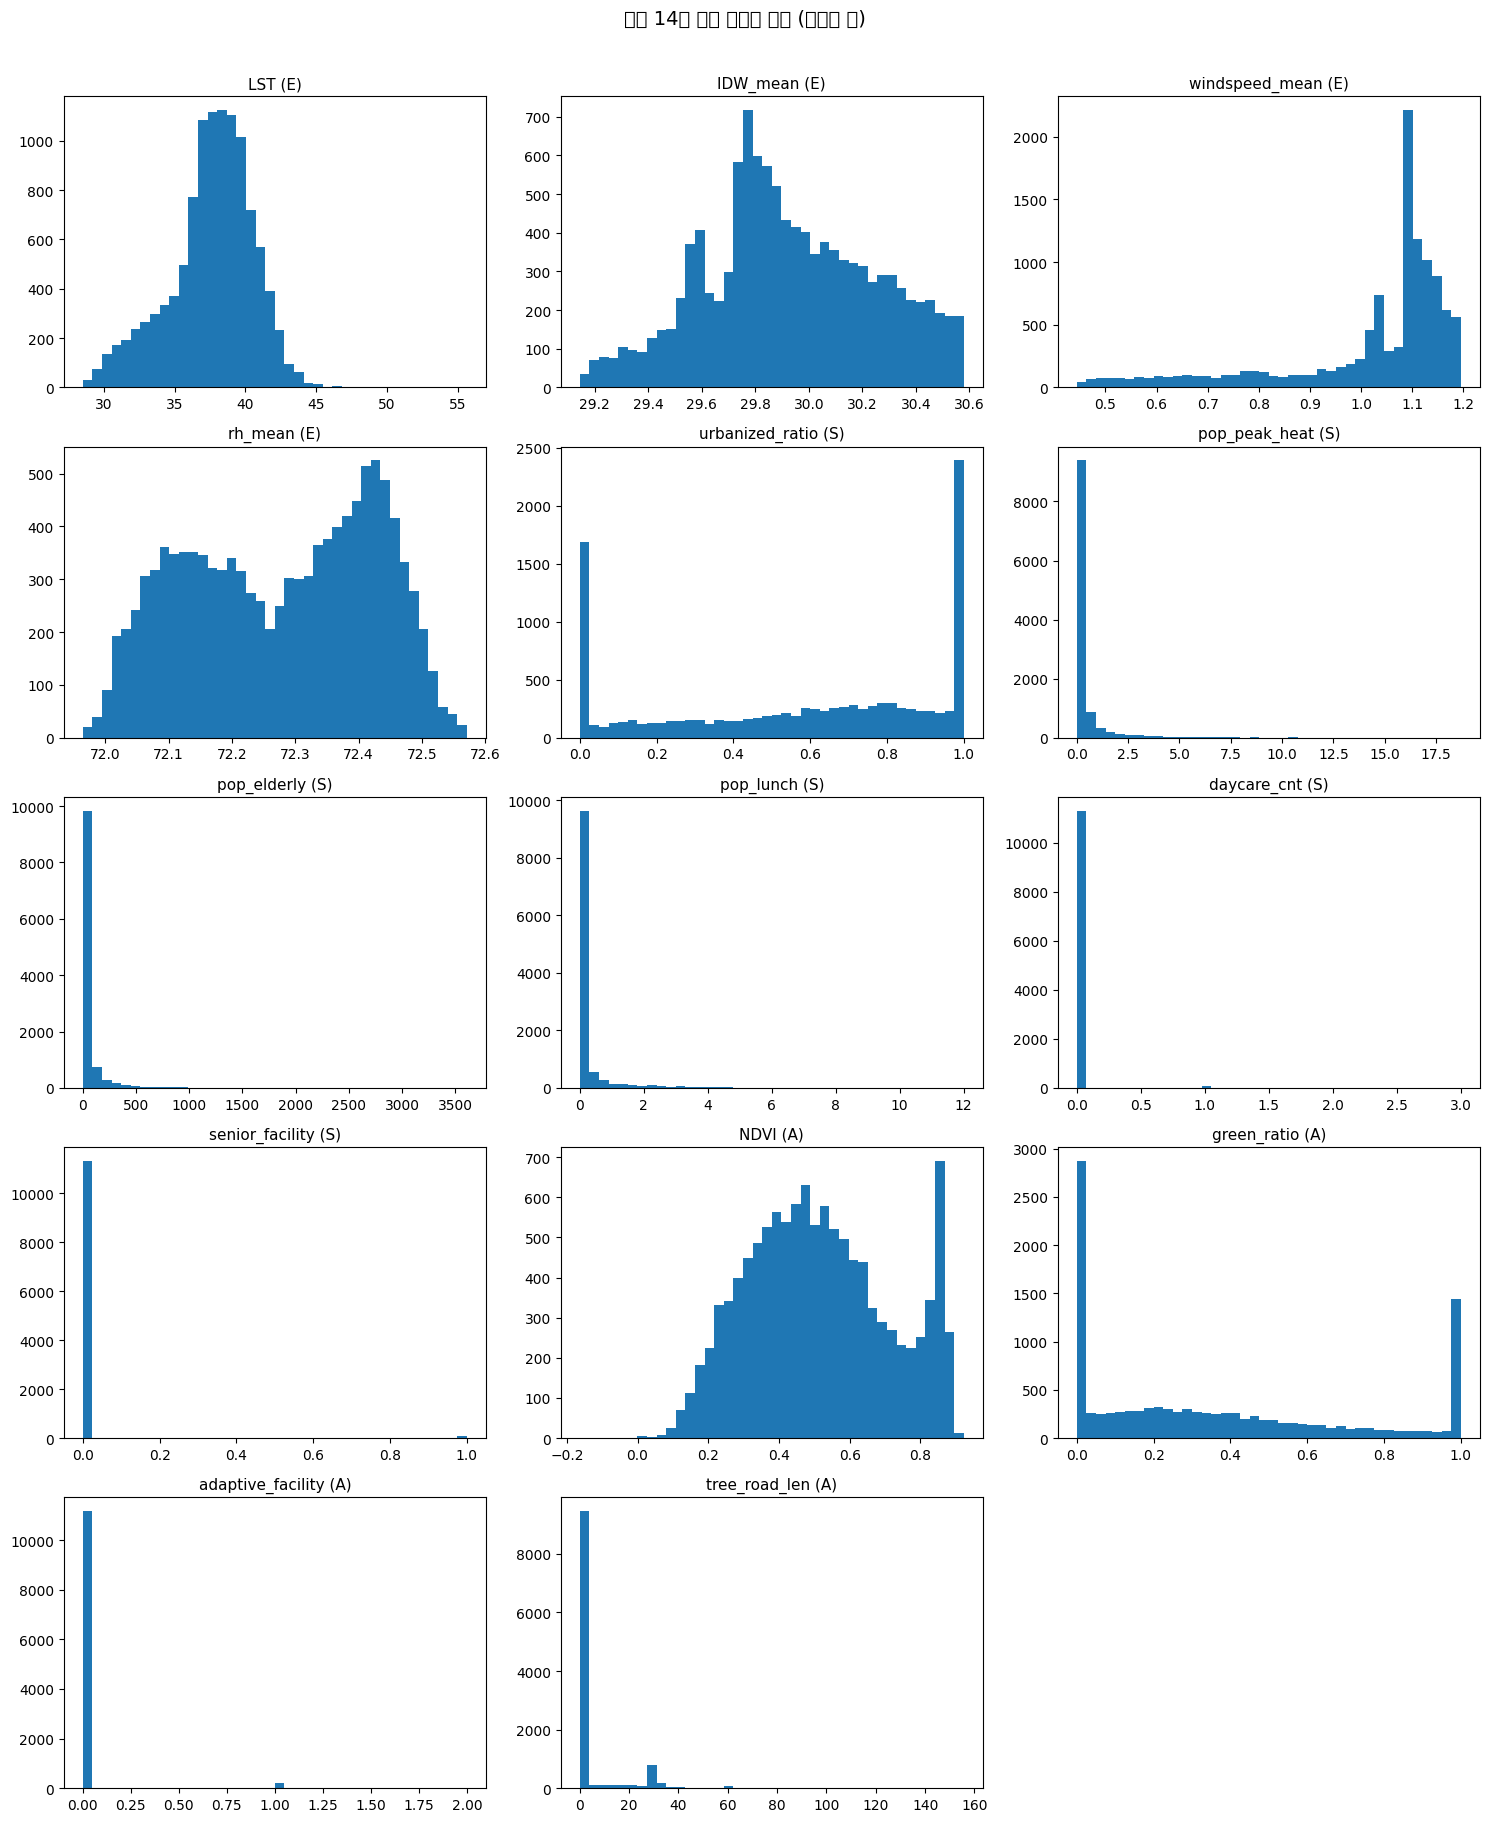

저장 완료: hist_14indicators_final.png


In [2]:
## 15-2: 최종 14개 지표 통합 히스토그램 (한 패널, 축별 그룹핑)

import matplotlib.pyplot as plt

col_label_map = {
    # E축 (4)
    'LST_C_mean_5scene': 'LST (E)',
    'IDW_mean': 'IDW_mean (E)',
    'windspeed_mean': 'windspeed_mean (E)',
    'rh_mean': 'rh_mean (E)',
    # S축 (6)
    'LC1_100_시가화건조지역_ratio': 'urbanized_ratio (S)',
    'pop_peak_h': 'pop_peak_heat (S)',
    'pop_elderl': 'pop_elderly (S)',
    'pop_lunch_': 'pop_lunch (S)',
    'daycare_cnt': 'daycare_cnt (S)',
    'senior_facility_total': 'senior_facility (S)',
    # A축 (4)
    'NDVI_mean_5scene': 'NDVI (A)',
    'GREEN_ratio_LC': 'green_ratio (A)',
    'adaptive_facility_total': 'adaptive_facility (A)',
    'tree_road_len': 'tree_road_len (A)',
}

fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

for i, (col, label) in enumerate(col_label_map.items()):
    axes[i].hist(df[col].dropna(), bins=40)
    axes[i].set_title(label, fontsize=11)

for j in range(len(col_label_map), len(axes)):
    axes[j].axis('off')

plt.suptitle('최종 14개 지표 원본값 분포 (표준화 전)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('hist_14indicators_final.png', dpi=150, bbox_inches='tight')
plt.show()

print("저장 완료: hist_14indicators_final.png")

03번 링크 수: 3462
OSM 인도 링크 수: 3130
03번 기준 노드/엣지: 2740 3462
OSM 인도 추가 후 노드/엣지: 9000 6592
스냅 매칭: 4464 / 6260
연결 후 전체 노드/엣지: 9000 11056
최종 노드/엣지: 7449 10278


findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Font family 'NanumGothic' not found.
findfont: Fon

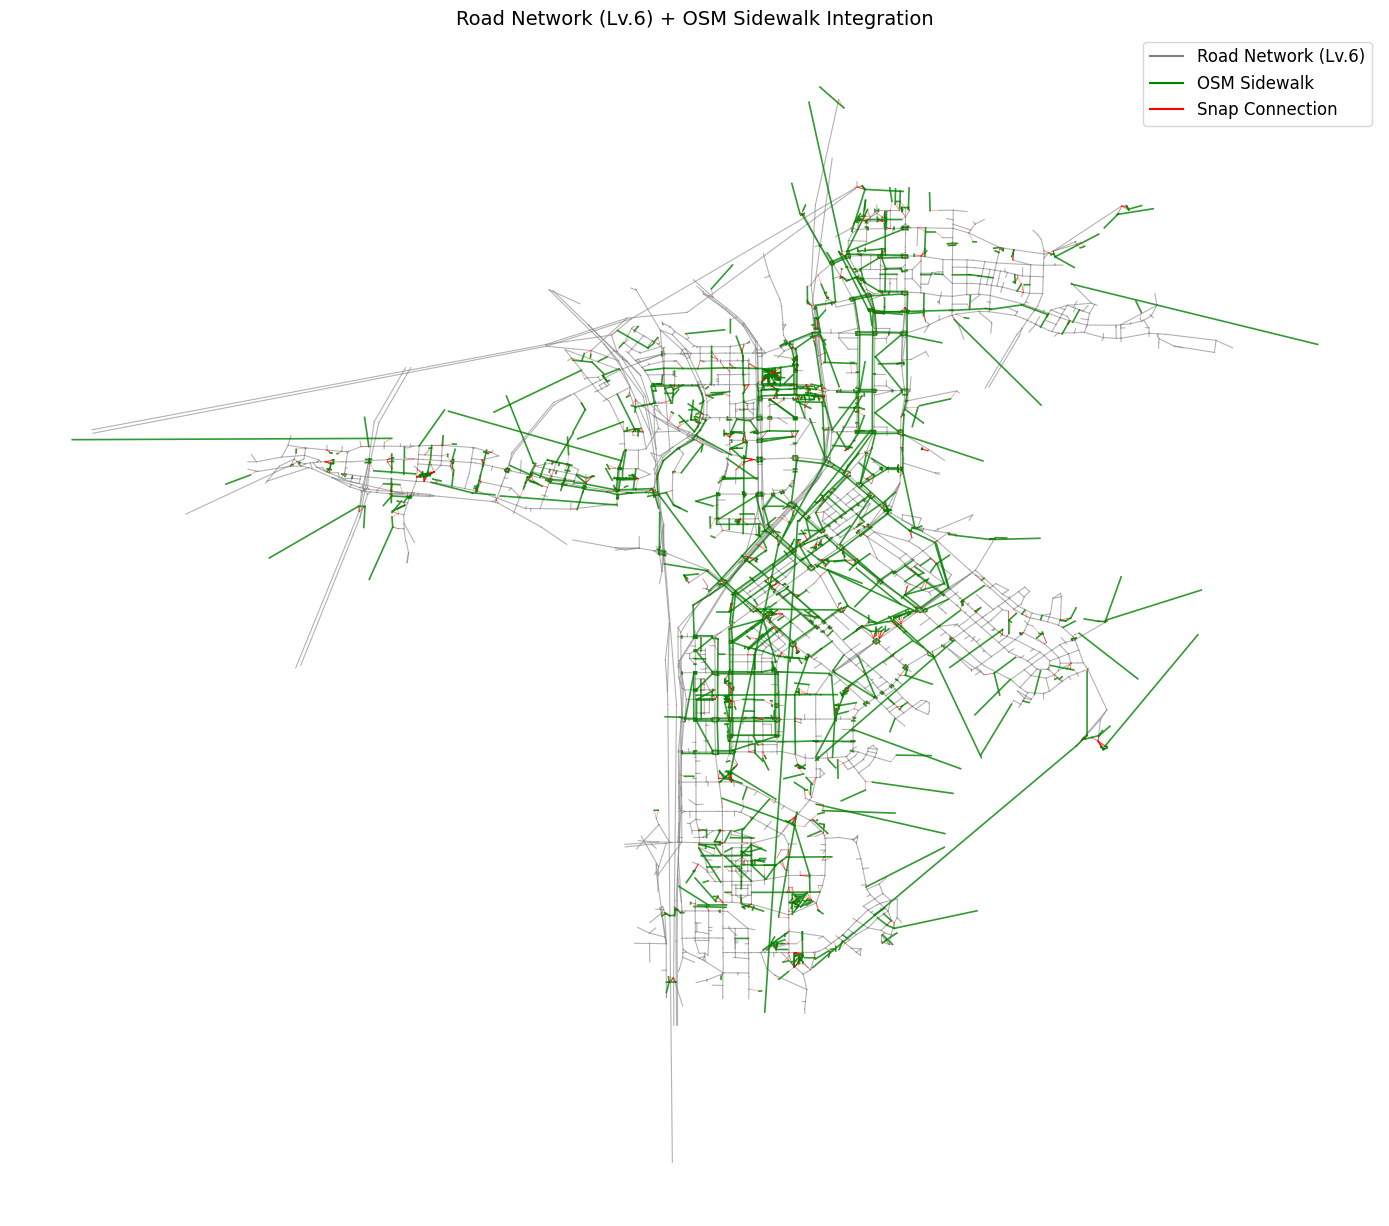

저장 완료: road_network_visualization_v3.png


In [5]:
## 15-3: 도로망 시각화 처음부터 재구축 (영문 라벨, 인덱스 문제 회피)

import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
from shapely.geometry import Point
from scipy.spatial import cKDTree
import numpy as np

# 1) 03번 도로망 불러오기
road_gdf = gpd.read_file('03._상세도로망_lev6.geojson')  # EPSG:4326
print("03번 링크 수:", len(road_gdf))

# 2) OSM 인도 데이터 불러오기 (bbox로 읽어서 속도 개선)
bbox = (127.05, 37.33, 127.16, 37.43)
osm_clip = gpd.read_file('gis_osm_roads_free_1.shp', bbox=bbox)
footway_types = ['footway', 'path', 'pedestrian', 'steps']
sidewalk = osm_clip[osm_clip['fclass'].isin(footway_types)].copy()
sidewalk = sidewalk.reset_index(drop=True)  # 인덱스 0부터 새로 정렬 (이번 실행 내에서만 일관되면 충분)
print("OSM 인도 링크 수:", len(sidewalk))

# 3) 그래프 새로 구축
G = nx.Graph()

# 3-1) 03번 엣지 추가
for _, row in road_gdf.iterrows():
    G.add_edge(
        str(row['up_f_node']), str(row['up_t_node']),
        weight=row['length'] * 1000,
        link_id=row['link_id'], source='road_03'
    )
print("03번 기준 노드/엣지:", G.number_of_nodes(), G.number_of_edges())

# 3-2) 노드 좌표 딕셔너리 (03번)
node03_coords = {}
for _, row in road_gdf.iterrows():
    coords = list(row.geometry.coords)
    if len(coords) < 2:
        continue
    node03_coords[str(row['up_f_node'])] = Point(coords[0])
    node03_coords[str(row['up_t_node'])] = Point(coords[-1])

# 3-3) OSM 인도 엣지 + 좌표 (이번 실행 내 인덱스로 일관되게 생성)
sidewalk_5186 = sidewalk.to_crs(epsg=5186)
osm_node_coords = {}

for idx, row in sidewalk.iterrows():
    coords = list(row.geometry.coords)
    if len(coords) < 2:
        continue
    start_node = f"osm_{idx}_start"
    end_node = f"osm_{idx}_end"
    length = sidewalk_5186.iloc[idx].geometry.length

    G.add_edge(start_node, end_node, weight=length,
               link_id=f"osm_{idx}", source='osm_sidewalk')
    osm_node_coords[start_node] = Point(coords[0])
    osm_node_coords[end_node] = Point(coords[-1])

print("OSM 인도 추가 후 노드/엣지:", G.number_of_nodes(), G.number_of_edges())

# 3-4) 스냅 연결 (반경 100m, cKDTree)
node03_ids_arr = list(node03_coords.keys())
node03_pts_arr = np.array([[p.x, p.y] for p in node03_coords.values()])
tree = cKDTree(node03_pts_arr)

osm_ids_arr = list(osm_node_coords.keys())
osm_pts_arr = np.array([[p.x, p.y] for p in osm_node_coords.values()])

SNAP_THRESHOLD_DEG = 100.0 / 88000  # 100m를 위경도 근사 변환 (약 1도=88km)
dists, idxs = tree.query(osm_pts_arr)

snap_count = 0
for osm_id, dist, idx in zip(osm_ids_arr, dists, idxs):
    if dist <= SNAP_THRESHOLD_DEG:
        nearest_03_id = node03_ids_arr[idx]
        G.add_edge(osm_id, nearest_03_id, weight=dist * 88000, source='snap_connection')
        snap_count += 1

print(f"스냅 매칭: {snap_count} / {len(osm_node_coords)}")
print("연결 후 전체 노드/엣지:", G.number_of_nodes(), G.number_of_edges())

# 3-5) 최대 연결컴포넌트만 추출
components = list(nx.connected_components(G))
largest_cc = max(components, key=len)
G_main = G.subgraph(largest_cc).copy()
print("최종 노드/엣지:", G_main.number_of_nodes(), G_main.number_of_edges())

# 4) 시각화 (영문 라벨)
all_node_coords = {**node03_coords, **osm_node_coords}

fig, ax = plt.subplots(figsize=(14, 14))

for u, v, data in G_main.edges(data=True):
    if u not in all_node_coords or v not in all_node_coords:
        continue
    p1 = all_node_coords[u]
    p2 = all_node_coords[v]

    source = data.get('source', 'road_03')
    if source == 'road_03':
        color, lw, alpha = 'gray', 0.8, 0.6
    elif source == 'osm_sidewalk':
        color, lw, alpha = 'green', 1.2, 0.8
    else:
        color, lw, alpha = 'red', 0.5, 0.4

    ax.plot([p1.x, p2.x], [p1.y, p2.y], color=color, linewidth=lw, alpha=alpha)

ax.plot([], [], color='gray', label='Road Network (Lv.6)')
ax.plot([], [], color='green', label='OSM Sidewalk')
ax.plot([], [], color='red', label='Snap Connection')
ax.legend(loc='upper right', fontsize=12)

ax.set_title('Road Network (Lv.6) + OSM Sidewalk Integration', fontsize=14)
ax.set_aspect('equal')
ax.axis('off')
plt.tight_layout()
plt.savefig('road_network_visualization_v3.png', dpi=150, bbox_inches='tight')
plt.show()

print("저장 완료: road_network_visualization_v3.png")